# V5.4 — Soft-stop monitor поверх Semantic active v3

В этом ноутбуке проверяется не новый Pair Generator, а **мягкий маркер остановки**.

Главная идея: `Semantic active v3` продолжает задавать вопросы все 25 шагов, но `Convergence Monitor` отмечает момент, когда продукт мог бы сказать пользователю: *профиль уже достаточно стабильный, можно сохранить или продолжить уточнение*.

Так мы отделяем:

- качество полной 25-step сессии;
- качество на момент recommended stop;
- дополнительный выигрыш после recommended stop;
- число шагов, которое можно было бы сэкономить.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / 'personalization').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('ROOT:', ROOT)

ROOT: C:\Users\makcc\PycharmProjects\EarLoop\research\eq_personalization


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from personalization.plotting import use_article_style
from personalization.batch_eval import win_rates_vs_baseline
from personalization.safe_anchor_challenger_v51 import V51_STRATEGY_NAME
from personalization.safe_anchor_challenger_v52 import V52_STRATEGY_NAME
from personalization.safe_anchor_challenger_v53 import V53_STRATEGY_NAME
from personalization.soft_stop_monitor_v54 import (
    V54_DISPLAY_NAMES,
    V54_STRATEGY_NAME,
    run_v54_comparison_on_dataset,
    save_v54_outputs,
    source_usage_table_v54,
    summarize_v54_sessions,
)

use_article_style()

In [3]:
DATASET_PATH = ROOT / 'outputs' / 'datasets' / 'synthetic_users_v21.csv'
FIG_DIR = ROOT / 'outputs' / 'figures'
TABLE_DIR = ROOT / 'outputs' / 'tables'
METRICS_DIR = ROOT / 'outputs' / 'metrics'

SAMPLE_PER_MODE = 50  # None или 0 — полный датасет
N_STEPS = 25

dataset = pd.read_csv(DATASET_PATH)

if SAMPLE_PER_MODE:
    parts = []
    for _, group in dataset.groupby('target_mode'):
        parts.append(group.sample(n=min(SAMPLE_PER_MODE, len(group)), random_state=42))
    dataset_eval = pd.concat(parts, axis=0).reset_index(drop=True)
else:
    dataset_eval = dataset.copy()

dataset_eval['target_mode'].value_counts()

target_mode
archetype8d    50
random8d       50
semantic4d     50
semantic6d     50
Name: count, dtype: int64

## Запуск эксперимента

Сравнение включает:

- `Semantic active v3` — полный baseline на 25 шагов;
- `V5.2` — hard stop после confirmation;
- `V5.3` — confirmation gate;
- `V5.4` — **soft-stop marker**, без остановки оптимизации;
- дополнительные baseline-стратегии для контекста.

In [5]:
sessions, steps, curves = run_v54_comparison_on_dataset(
    dataset_eval,
    baseline_strategies=('semantic_active_v21', 'candidate_pool_active'),
    include_v51=True,
    include_v52=True,
    include_v53=True,
    n_steps=N_STEPS,
    step_scale=0.6,
    lr=0.25,
    clip_value=2.0,
)

summary = summarize_v54_sessions(sessions)
win_rates = win_rates_vs_baseline(sessions, baseline='semantic_active_v21')
source_usage = source_usage_table_v54(steps)

save_v54_outputs(sessions, steps, summary, win_rates, source_usage, METRICS_DIR)

summary.head()

,target_mode,strategy,users,mean_used_steps,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,...,mean_extra_gain_after_stop,mean_quality_loss_if_stop,mean_retained_quality_at_stop_pct,mean_steps_saved_if_stop,mean_continued_steps_after_stop,mean_pair_distance,mean_audibility_score,mean_acceptability_score,mean_midrange_penalty,mean_applied_lr
2,archetype8d,semantic_active_soft_stop_monitor_v54,50,25.00,1.095608,0.360155,0.098427,0.263306,0.561904,59.974178,...,0.072398,0.072398,80.289344,9.82,9.82,1.020000,1.000000,1.000000,0.000000,0.250000
3,archetype8d,semantic_active_v21,50,25.00,1.095608,0.360155,0.098427,0.263306,0.561904,59.974178,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,archetype8d,semantic_backbone_confirmation_gate_v53,50,21.14,1.095608,0.411584,0.169547,0.324707,0.572912,52.292096,...,NaN,NaN,NaN,NaN,NaN,0.777551,0.668243,0.988787,0.011923,0.186684
1,archetype8d,safe_anchor_challenger_v51,50,25.00,1.095608,0.422383,0.195692,0.372829,0.595770,54.650715,...,NaN,NaN,NaN,NaN,NaN,0.648915,0.663967,0.985910,0.018757,0.146844
5,archetype8d,semantic_backbone_confirmation_v52,50,16.06,1.095608,0.459850,0.208367,0.373403,0.589182,50.942234,...,NaN,NaN,NaN,NaN,NaN,0.593211,0.679401,0.989052,0.011698,0.141752


In [6]:
TARGET_MODE_DISPLAY_NAMES = {
    'random8d': 'Random 8D',
    'semantic4d': 'Semantic 4D',
    'semantic6d': 'Semantic 6D',
    'archetype8d': 'Archetype 8D',
}
TARGET_MODE_ORDER = ['random8d', 'semantic4d', 'semantic6d', 'archetype8d']
STRATEGY_ORDER = [
    'semantic_active_v21',
    'candidate_pool_active',
    V51_STRATEGY_NAME,
    V52_STRATEGY_NAME,
    V53_STRATEGY_NAME,
    V54_STRATEGY_NAME,
]

def add_display_columns(df):
    out = df.copy()
    out['target_mode_display'] = out['target_mode'].map(TARGET_MODE_DISPLAY_NAMES).fillna(out['target_mode'])
    out['strategy_display'] = out['strategy'].map(V54_DISPLAY_NAMES).fillna(out['strategy'])
    return out

summary_display = add_display_columns(summary)
summary_display

,target_mode,strategy,users,mean_used_steps,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,...,mean_retained_quality_at_stop_pct,mean_steps_saved_if_stop,mean_continued_steps_after_stop,mean_pair_distance,mean_audibility_score,mean_acceptability_score,mean_midrange_penalty,mean_applied_lr,target_mode_display,strategy_display
2,archetype8d,semantic_active_soft_stop_monitor_v54,50,25.00,1.095608,0.360155,0.098427,0.263306,0.561904,59.974178,...,80.289344,9.82,9.82,1.020000,1.000000,1.000000,0.000000,0.250000,Archetype 8D,Semantic active v3 + soft-stop monitor v5.4
3,archetype8d,semantic_active_v21,50,25.00,1.095608,0.360155,0.098427,0.263306,0.561904,59.974178,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Archetype 8D,Semantic active v3
4,archetype8d,semantic_backbone_confirmation_gate_v53,50,21.14,1.095608,0.411584,0.169547,0.324707,0.572912,52.292096,...,NaN,NaN,NaN,0.777551,0.668243,0.988787,0.011923,0.186684,Archetype 8D,Semantic backbone + confirmation gate v5.3
1,archetype8d,safe_anchor_challenger_v51,50,25.00,1.095608,0.422383,0.195692,0.372829,0.595770,54.650715,...,NaN,NaN,NaN,0.648915,0.663967,0.985910,0.018757,0.146844,Archetype 8D,Conservative anchor-challenger v5.1
5,archetype8d,semantic_backbone_confirmation_v52,50,16.06,1.095608,0.459850,0.208367,0.373403,0.589182,50.942234,...,NaN,NaN,NaN,0.593211,0.679401,0.989052,0.011698,0.141752,Archetype 8D,Semantic backbone + confirmation v5.2
0,archetype8d,candidate_pool_active,50,25.00,1.095608,0.492750,0.116158,0.340776,0.625183,39.785242,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Archetype 8D,Candidate pool active
6,random8d,candidate_pool_active,50,25.00,2.121827,0.970351,0.411712,0.944272,1.495394,55.091709,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Random 8D,Candidate pool active
8,random8d,semantic_active_soft_stop_monitor_v54,50,25.00,2.121827,1.437350,0.491156,1.409565,1.665743,31.383912,...,41.640206,10.00,10.00,1.020000,1.000000,1.000000,0.000000,0.250000,Random 8D,Semantic active v3 + soft-stop monitor v5.4
9,random8d,semantic_active_v21,50,25.00,2.121827,1.437350,0.491156,1.409565,1.665743,31.383912,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Random 8D,Semantic active v3
10,random8d,semantic_backbone_confirmation_gate_v53,50,20.80,2.121827,1.519515,0.494196,1.490149,1.682884,27.942848,...,NaN,NaN,NaN,0.764647,0.684813,0.986538,0.014107,0.183372,Random 8D,Semantic backbone + confirmation gate v5.3


## Итоговое качество

Важно: `V5.4` должен быть близок к `Semantic active v3`, потому что генератор и update остаются теми же. Отличие — в наличии soft-stop marker и диагностике качества на момент рекомендуемой остановки.

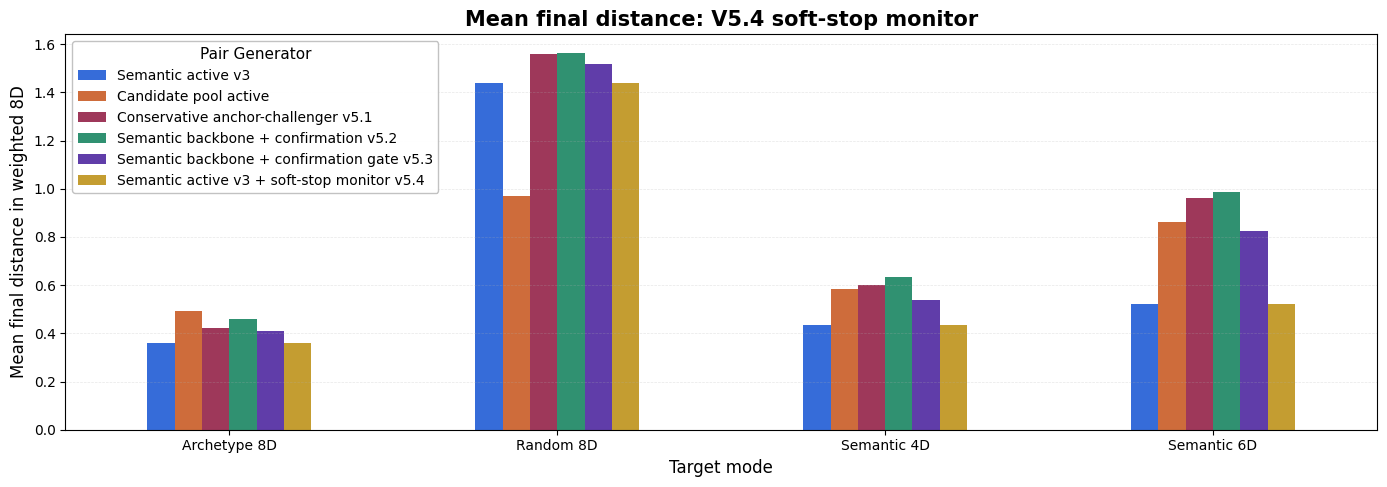

In [7]:
df = summary_display[summary_display['strategy'].isin(STRATEGY_ORDER)].copy()
df['target_mode'] = pd.Categorical(df['target_mode'], TARGET_MODE_ORDER, ordered=True)
df['strategy'] = pd.Categorical(df['strategy'], STRATEGY_ORDER, ordered=True)
df = df.sort_values(['target_mode', 'strategy'])

pivot = df.pivot(index='target_mode_display', columns='strategy_display', values='mean_final_distance')
cols = [V54_DISPLAY_NAMES[s] for s in STRATEGY_ORDER if V54_DISPLAY_NAMES.get(s) in pivot.columns]
pivot = pivot[cols]

fig, ax = plt.subplots(figsize=(14, 5), facecolor='white')
pivot.plot(kind='bar', ax=ax)
ax.set_title('Mean final distance: V5.4 soft-stop monitor', fontsize=15, fontweight='bold')
ax.set_xlabel('Target mode')
ax.set_ylabel('Mean final distance in weighted 8D')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.legend(title='Pair Generator', frameon=True, facecolor='white', edgecolor='0.75')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

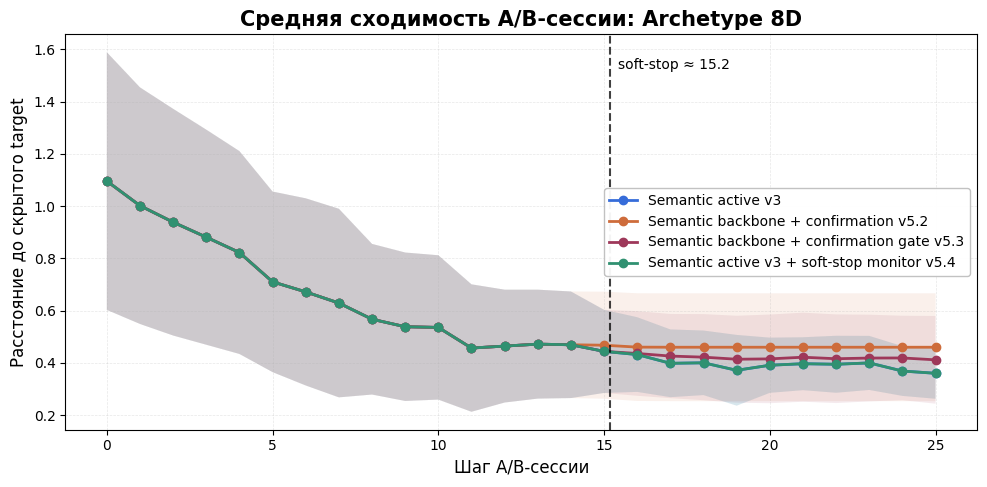

In [8]:
mode = 'archetype8d'
fig, ax = plt.subplots(figsize=(10, 5), facecolor='white')
for strategy in ['semantic_active_v21', V52_STRATEGY_NAME, V53_STRATEGY_NAME, V54_STRATEGY_NAME]:
    arr = curves.get(mode, {}).get(strategy)
    if arr is None or len(arr) == 0:
        continue
    mean = arr.mean(axis=0)
    std = arr.std(axis=0)
    x = np.arange(len(mean))
    ax.plot(x, mean, marker='o', linewidth=2, label=V54_DISPLAY_NAMES.get(strategy, strategy))
    ax.fill_between(x, mean - std, mean + std, alpha=0.10)

v54_row = summary[(summary['target_mode'] == 'archetype8d') & (summary['strategy'] == V54_STRATEGY_NAME)]
if not v54_row.empty:
    stop_step = float(v54_row['mean_recommended_stop_step'].iloc[0])
    ax.axvline(stop_step, color='black', linestyle='--', linewidth=1.5, alpha=0.75)
    ax.text(stop_step + 0.25, ax.get_ylim()[1] * 0.92, f'soft-stop ≈ {stop_step:.1f}', fontsize=10)

ax.set_title('Средняя сходимость A/B-сессии: Archetype 8D', fontsize=15, fontweight='bold')
ax.set_xlabel('Шаг A/B-сессии')
ax.set_ylabel('Расстояние до скрытого target')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(frameon=True, facecolor='white', edgecolor='0.75')
plt.tight_layout()
plt.show()

## Soft-stop диагностика

Эти метрики отвечают на вопрос: **что потеряем, если пользователь остановится в рекомендованный момент, и что выиграем, если он продолжит?**

In [10]:
cols = [
    'target_mode',
    'strategy',
    'users',
    'recommended_stop_rate',
    'mean_recommended_stop_step',
    'mean_distance_at_recommended_stop',
    'mean_final_distance',
    'mean_extra_gain_after_stop',
    'mean_steps_saved_if_stop',
    'mean_retained_quality_at_stop_pct',
]
soft_summary = summary[summary['strategy'] == V54_STRATEGY_NAME][cols].copy()
soft_summary['target_mode_display'] = soft_summary['target_mode'].map(TARGET_MODE_DISPLAY_NAMES)
soft_summary

,target_mode,strategy,users,recommended_stop_rate,mean_recommended_stop_step,mean_distance_at_recommended_stop,mean_final_distance,mean_extra_gain_after_stop,mean_steps_saved_if_stop,mean_retained_quality_at_stop_pct,target_mode_display
2,archetype8d,semantic_active_soft_stop_monitor_v54,50,1.0,15.18,0.432553,0.360155,0.072398,9.82,80.289344,Archetype 8D
8,random8d,semantic_active_soft_stop_monitor_v54,50,1.0,15.00,1.557218,1.437350,0.119869,10.00,41.640206,Random 8D
14,semantic4d,semantic_active_soft_stop_monitor_v54,50,1.0,15.00,0.614404,0.435656,0.178747,10.00,94.014664,Semantic 4D
20,semantic6d,semantic_active_soft_stop_monitor_v54,50,1.0,15.00,0.905468,0.522478,0.382990,10.00,79.636633,Semantic 6D


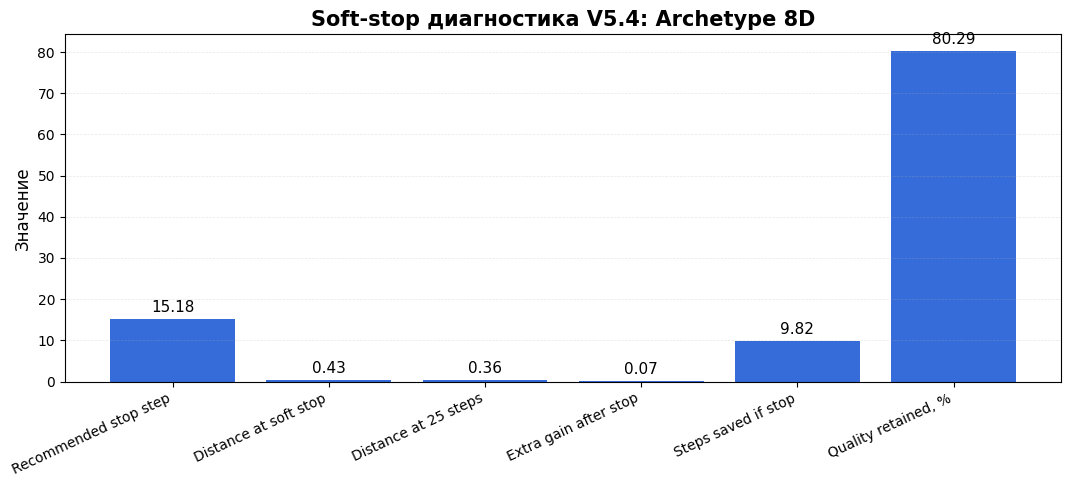

In [11]:
v54 = summary[(summary['target_mode'] == 'archetype8d') & (summary['strategy'] == V54_STRATEGY_NAME)]
metrics = [
    ('mean_recommended_stop_step', 'Recommended stop step'),
    ('mean_distance_at_recommended_stop', 'Distance at soft stop'),
    ('mean_final_distance', 'Distance at 25 steps'),
    ('mean_extra_gain_after_stop', 'Extra gain after stop'),
    ('mean_steps_saved_if_stop', 'Steps saved if stop'),
    ('mean_retained_quality_at_stop_pct', 'Quality retained, %'),
]
values = [float(v54[m].iloc[0]) for m, _ in metrics]
labels = [label for _, label in metrics]

fig, ax = plt.subplots(figsize=(11, 5), facecolor='white')
bars = ax.bar(labels, values)
ax.set_title('Soft-stop диагностика V5.4: Archetype 8D', fontsize=15, fontweight='bold')
ax.set_ylabel('Значение')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.bar_label(bars, fmt='%.2f', padding=3)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

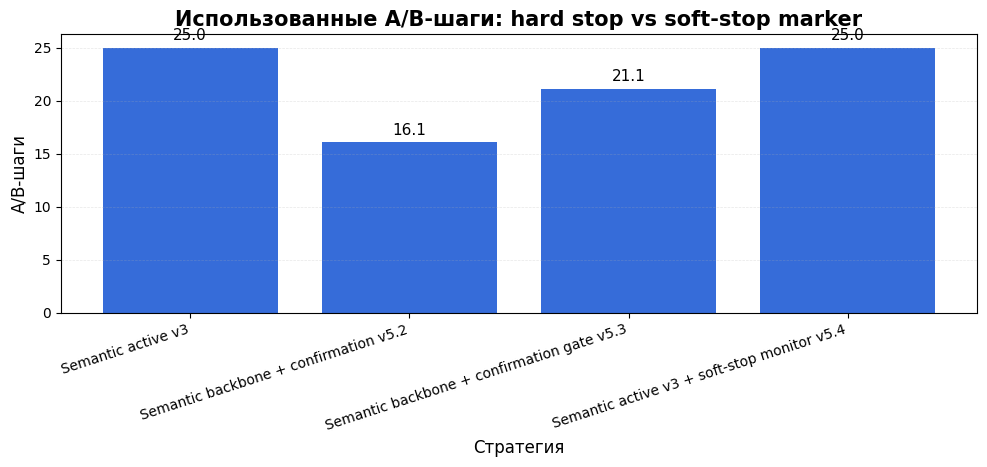

In [12]:
df = summary_display[(summary_display['target_mode'] == 'archetype8d') & (summary_display['strategy'].isin(['semantic_active_v21', V52_STRATEGY_NAME, V53_STRATEGY_NAME, V54_STRATEGY_NAME]))].copy()
order = ['semantic_active_v21', V52_STRATEGY_NAME, V53_STRATEGY_NAME, V54_STRATEGY_NAME]
df['strategy'] = pd.Categorical(df['strategy'], order, ordered=True)
df = df.sort_values('strategy')

fig, ax = plt.subplots(figsize=(10, 4.8), facecolor='white')
bars = ax.bar(df['strategy_display'], df['mean_used_steps'])
ax.set_title('Использованные A/B-шаги: hard stop vs soft-stop marker', fontsize=15, fontweight='bold')
ax.set_xlabel('Стратегия')
ax.set_ylabel('A/B-шаги')
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
ax.bar_label(bars, fmt='%.1f', padding=3)
plt.xticks(rotation=18, ha='right')
plt.tight_layout()
plt.show()